In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

In [37]:
import pandas as pd

train_df = pd.read_csv('fraudTrain.csv')
test_df = pd.read_csv('fraudTest.csv')

In [38]:
print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)

train_df.head()

Train Shape: (1296675, 23)
Test Shape: (555719, 23)


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [39]:
train_df.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')

In [40]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [41]:
train_df.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,6.483370e+05,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03
std,3.743180e+05,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02
min,0.000000e+00,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,3.241685e+05,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00
50%,6.483370e+05,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00
75%,9.725055e+05,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00
max,1.296674e+06,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00


In [7]:
train_df['is_fraud'].value_counts()

,count
is_fraud,
0.0,50139
1.0,461


In [42]:
train_df.isnull().sum()

,0
Unnamed: 0,0
trans_date_trans_time,0
cc_num,0
merchant,0
category,0
amt,0
first,0
last,0
gender,0
street,0


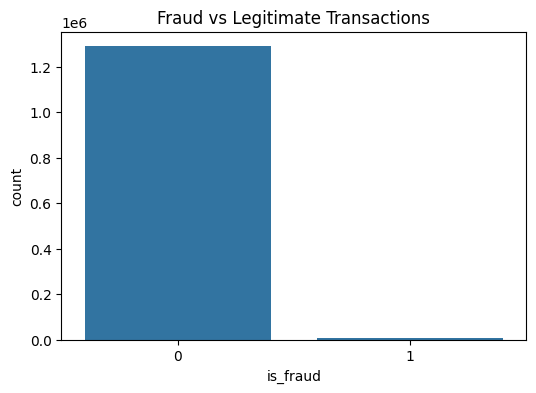

In [44]:
plt.figure(figsize=(6,4))

sns.countplot(x='is_fraud', data=train_df)

plt.title("Fraud vs Legitimate Transactions")
plt.show()

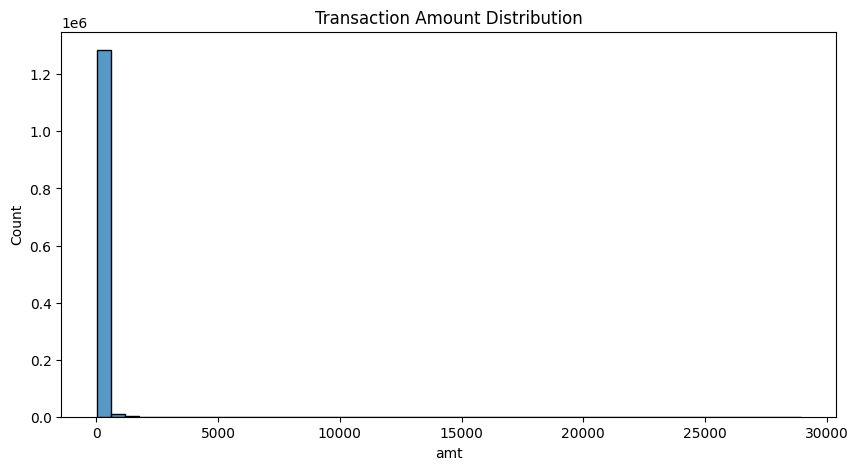

In [45]:
plt.figure(figsize=(10,5))

sns.histplot(train_df['amt'], bins=50)

plt.title("Transaction Amount Distribution")
plt.show()

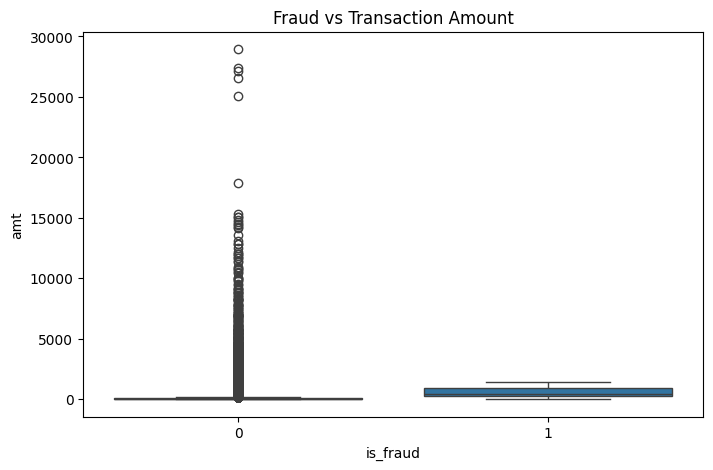

In [46]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='is_fraud',
    y='amt',
    data=train_df
)

plt.title("Fraud vs Transaction Amount")
plt.show()

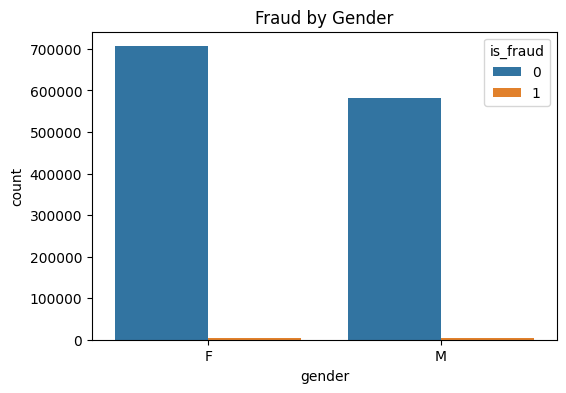

In [47]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='gender',
    hue='is_fraud',
    data=train_df
)

plt.title("Fraud by Gender")
plt.show()

In [48]:
drop_cols = [
    'Unnamed: 0',
    'trans_date_trans_time',
    'cc_num',
    'first',
    'last',
    'street',
    'trans_num'
]

train_df = train_df.drop(columns=drop_cols)
test_df = test_df.drop(columns=drop_cols)

In [49]:
from datetime import datetime

train_df['dob'] = pd.to_datetime(train_df['dob'])
test_df['dob'] = pd.to_datetime(test_df['dob'])

current_year = datetime.now().year

train_df['age'] = current_year - train_df['dob'].dt.year
test_df['age'] = current_year - test_df['dob'].dt.year

train_df.drop('dob', axis=1, inplace=True)
test_df.drop('dob', axis=1, inplace=True)

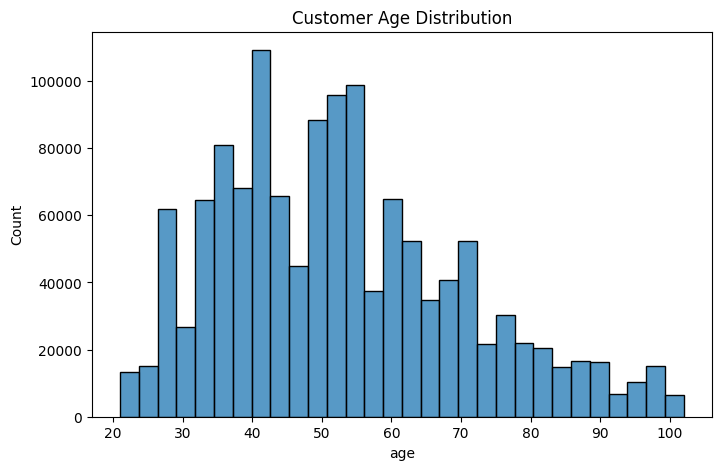

In [50]:
plt.figure(figsize=(8,5))

sns.histplot(
    train_df['age'],
    bins=30
)

plt.title("Customer Age Distribution")
plt.show()

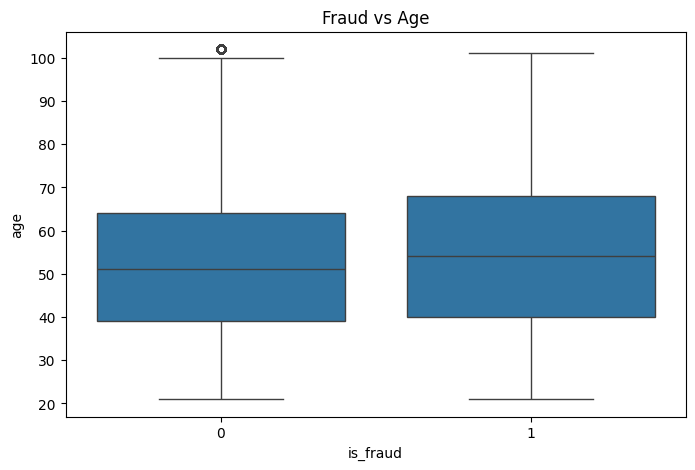

In [51]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='is_fraud',
    y='age',
    data=train_df
)

plt.title("Fraud vs Age")
plt.show()

In [53]:
numeric_cols = train_df.select_dtypes(
    include=np.number
)

corr = numeric_cols.corr()

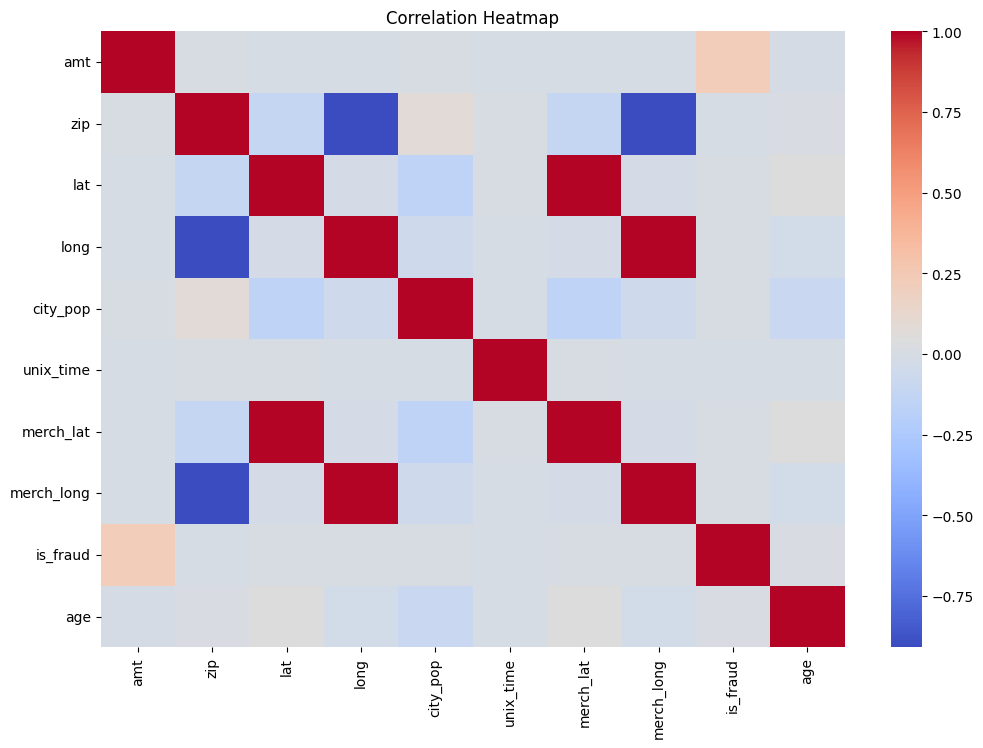

In [54]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

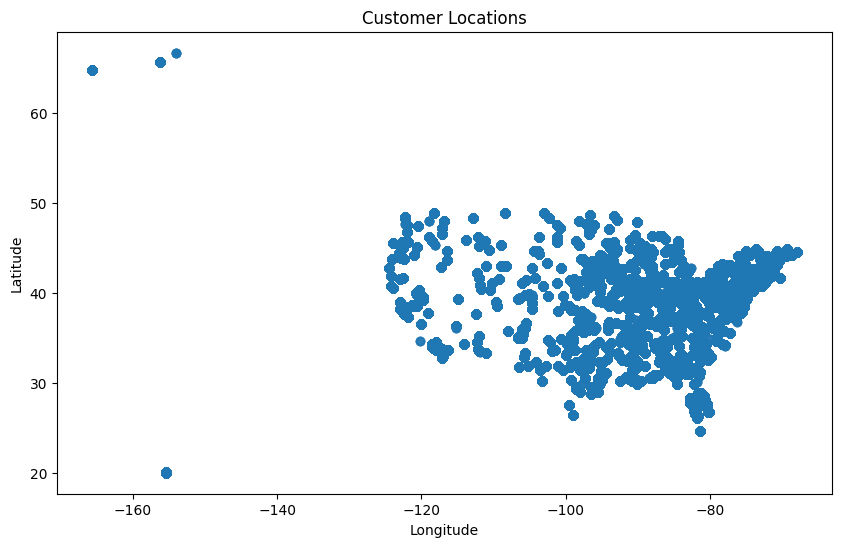

In [55]:
plt.figure(figsize=(10,6))

plt.scatter(
    train_df['long'],
    train_df['lat'],
    alpha=0.3
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Customer Locations")
plt.show()

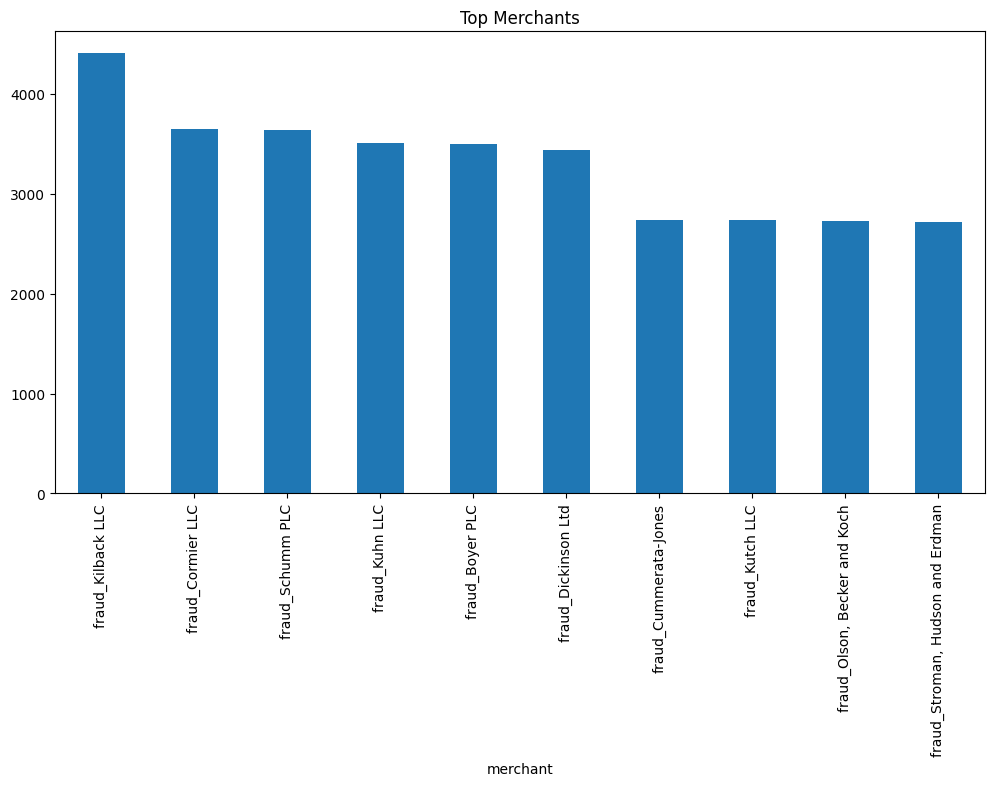

In [57]:
plt.figure(figsize=(12,6))

train_df['merchant'].value_counts().head(10).plot(
    kind='bar'
)

plt.title("Top Merchants")
plt.show()

In [58]:
train_df.select_dtypes(include='object').columns

Index(['merchant', 'category', 'gender', 'city', 'state', 'job'], dtype='object')

In [59]:
from sklearn.preprocessing import OrdinalEncoder

categorical_cols = [
    'merchant',
    'category',
    'gender',
    'city',
    'state',
    'job'
]

encoder = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

train_df[categorical_cols] = encoder.fit_transform(
    train_df[categorical_cols].astype(str)
)

test_df[categorical_cols] = encoder.transform(
    test_df[categorical_cols].astype(str)
)

In [60]:
train_df.head()

,merchant,category,amt,gender,city,state,zip,lat,long,city_pop,job,unix_time,merch_lat,merch_long,is_fraud,age
0,514.0,8.0,4.97,0.0,526.0,27.0,28654,36.0788,-81.1781,3495,370.0,1325376018,36.011293,-82.048315,0,38
1,241.0,4.0,107.23,0.0,612.0,47.0,99160,48.8878,-118.2105,149,428.0,1325376044,49.159047,-118.186462,0,48
2,390.0,0.0,220.11,1.0,468.0,13.0,83252,42.1808,-112.2620,4154,307.0,1325376051,43.150704,-112.154481,0,64
3,360.0,2.0,45.00,1.0,84.0,26.0,59632,46.2306,-112.1138,1939,328.0,1325376076,47.034331,-112.561071,0,59
4,297.0,9.0,41.96,1.0,216.0,45.0,24433,38.4207,-79.4629,99,116.0,1325376186,38.674999,-78.632459,0,40


In [61]:
X_train = train_df.drop('is_fraud', axis=1)
y_train = train_df['is_fraud']

X_test = test_df.drop('is_fraud', axis=1)
y_test = test_df['is_fraud']

In [62]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [63]:
print(train_df.isnull().sum())


merchant      0
category      0
amt           0
gender        0
city          0
state         0
zip           0
lat           0
long          0
city_pop      0
job           0
unix_time     0
merch_lat     0
merch_long    0
is_fraud      0
age           0
dtype: int64


In [64]:
train_df = train_df.dropna()
test_df = test_df.dropna()

In [65]:
X_train = train_df.drop('is_fraud', axis=1)
y_train = train_df['is_fraud']

X_test = test_df.drop('is_fraud', axis=1)
y_test = test_df['is_fraud']

In [66]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [67]:
print(train_df.shape)
print(test_df.shape)

(1296675, 16)
(555719, 16)


In [68]:
print("Train NaN:", train_df.isnull().sum().sum())
print("Test NaN:", test_df.isnull().sum().sum())

Train NaN: 0
Test NaN: 0


In [69]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_lr))

print(classification_report(y_test, y_pred_lr))

Accuracy: 0.9557564164622768
ROC-AUC: 0.8542636801418825
              precision    recall  f1-score   support

           0       1.00      0.96      0.98    553574
           1       0.06      0.75      0.12      2145

    accuracy                           0.96    555719
   macro avg       0.53      0.85      0.55    555719
weighted avg       1.00      0.96      0.97    555719

